In [1]:
import numpy as np
from glob import glob
import pickle
import matplotlib
import xarray as xr
import matplotlib.pyplot as plt
import math
# import datetime
# import time
from scipy.io import readsav
from pandas.core.common import flatten
from scipy import spatial, constants
import pyart
import pandas
from datetime import datetime, timedelta
import numpy as np
import pandas as pd

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.

## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [ ]:
import numpy as np

def knb_mc_sim(m,concentration,size,PROFILE_IN,zz,yy,xx,tree,masktree, LAM_arr,SEEDER = 10.,
               coords = [40e3,0.,40e3,0.,20e3,0.], 
               origin = [5e3,5e3,5e3]):

    #origin order is [z,y,x] because gridcoords is z,y,x
    print(origin)
    # print(coords)
    #coords is xmax,xmin, ymax,ymin, zmax,zmin
    
    #array for distance the particle traveled
    dist = np.zeros(m)

    # #make points and kdtree for cloud coordinates
    # zz,yy,xx = np.meshgrid(PROFILE_IN['z'].values, PROFILE_IN['y'].values,PROFILE_IN['x'].values,indexing='ij')
    # length = len(PROFILE_IN['x'])*len(PROFILE_IN['y'])*len(PROFILE_IN['z'])
    # xx = np.reshape(xx,length)
    # yy = np.reshape(yy,length)
    # zz = np.reshape(zz,length)
    # gridcoords = np.stack((zz,yy,xx),axis = 1) 
    # tree = spatial.KDTree(gridcoords)
    
    #Define your boundaries and arrays to hold when a boundary is crossed, specifically if using a hard lateral or vertical boundary
    s = np.size(coords)
    
    z_min = coords[5] #this is the bottom of the cloud
    z_max = coords[4] #this is the top of the cloud.
    x_min = coords[1] #this is the 1st face, the negative X-face
    x_max = coords[0] # this is the 2nd face, the positive X-face
    y_min = coords[3] #this is the 3rd face, the negative Y-face
    y_max = coords[2] #this is the 4th face, the positive Y-face
    
    ##########CONSTANTS###########
    #Asymmetry factor for a 10micron water drop in the visible spectral region.
    g = 0.87 #double?
    #single scattering albedo for a water droplet of 10 microns in the visible spectral region.
    w_0 = 0.99998

    #the radius of a typical cloud droplet
    a = 10**-5. #evaluate if e is a double, or long
    N = 10**8.
    LAM = 1./(2.*np.pi*(a**2.)*N)
    #comment for a 3d heterogenerous cloud
    # print(LAM)
#     N_dense = np.reshape(concentration,length)
#     a_arr = np.reshape(size,length)
#     a_arr = np.array([0 if math.isnan(i) else i for i in a_arr])
#     N_dense = np.array([0 if math.isnan(i) else i for i in N_dense])
    
#     # ######Check microphysical profile
#     height = PROFILE_IN['z'].values #reform(profile_in['profile'][:,2])
#     if np.nanmax(height) <= 100.:
#         height = height*1000.
#     #     ######Determine mean free path
#     #     #####(m) mean free path of photons with a uniform population of drops.
#     #     #LAM_ARR = reform(1./(2.*!dpi*(a_arr^2.)*N_dense))
#     LAM_arr = (1./(2.*math.pi*(a_arr**2.)*N_dense)) #make sure a_arr isn't creating a matrix
#     LAM_arr = np.nan_to_num(LAM_arr,posinf = 999999,neginf = 999999)
#     # LAM_arr = np.reshape(LAM_arr,[80,10,10])

#     #NOTE, WE USE A MEAN FREE PATH OF 200m here as the cloud boundary. It is on the user to determine if this is appropriate for THEIR CLOUD.
#     mask = np.where(LAM_arr <= 200)
#     mask = np.array(list(flatten(mask)))
#     if len(mask) == 0 :
#         print('no clouds here')
#         return
#     maskstack = np.stack((zz[mask],yy[mask],xx[mask]),axis=1)
#     masktree = spatial.KDTree(maskstack)
    
    #******
    # point = masktree.query(origin)
    # if point[0] >1100.:
    #     outofCloud = 1
    # else:
    #     outofCloud = 0
    
    
    #####calculate the array of possible scattering angles using the Henyey-Greenstein phase function
    N = 2001#e0
    mu_arr = np.zeros(N)
    mu_arr[0] = -1.#formerly 0D
    for i in np.arange(1,len(mu_arr)-1):
        mu_arr[i] = ((1. + g**2.)-((2.*g)/(N*(1. - g**2.)) + (1. + g**2. - 2.*g*mu_arr[i-1])**(-1./2.))**(-2.))/(2.*g)
        if mu_arr[i] > 1.:
            mu_arr[i] = 1.


    pp = np.arange(len(mu_arr),dtype = int)
    #*********
    
    x_arr = np.zeros(m)
    y_arr = np.zeros(m)
    z_arr = np.zeros(m)
    xprev_arr = np.zeros(m)
    yprev_arr = np.zeros(m)
    zprev_arr = np.zeros(m)
    zenith_arrout = np.zeros(m)
    azimuth_arrout = np.zeros(m)
    absorb = np.zeros(m)
 
    zenith_orig = np.zeros(m)
    azimuth_orig = np.zeros(m)
    seed1 = SEEDER
    seed2 = seed1 + 1
    seed3 = seed2 + 2
    seed4 = seed3 + 3
    seed5 = seed4 + 4
    seed6 = seed5 + 5
    seed7 = seed6 + 6
    seed8 = seed7 + 7
    seed9 = seed8 + 8

    #11/13/2024 Changed phi and theta to azimuth and zenith angles naming convention
    #11/13/2024 Note Phi is the angle from the positive x axis, theta is the angle from the positive z axis. This may be backwards from other conventions
    #changed on on 8/6/2024
    #;initial photon isotropically scattered directions
    rng = np.random.default_rng(seed = seed1)
    u = rng.uniform(0,1,m)#randomu(seed1,m)
    rng = np.random.default_rng(seed = seed2)
    azimuth_0 = rng.uniform(0,2.*math.pi,m)#v = randomu(seed2,m) 

    rng = np.random.default_rng(seed = seed3)
    coszenith = rng.uniform(-1,1,m)
    zenith_0 = np.arccos(coszenith)
    
    rng = np.random.default_rng(seed = seed4)
    ab_arr_m = rng.uniform(0,1, m)
    rng = np.random.default_rng(seed = seed5)
    r_m = rng.uniform(0,1,m) 
       


    #UNCOMMENT THIS FOR DISTRIBUTED LAMBDA
    LAM = LAM_arr[tree.query(origin)[1]]
    print(LAM)
    x_scat_0 = -LAM*np.log(r_m)
    
    #two cases:
    #1 Emitted in the cloud
    #1 emitted out of the cloud
    point = masktree.query(origin)
    if point[0] < 500.:
        emittedincloud = 1
    else: emittedincloud = 0
    

    
    
    rng = np.random.default_rng(seed = seed6)
    ind_m = rng.uniform(0,1,m) 
    

    rng = np.random.default_rng(seed = seed7)
    zenith_ind_m_seed = rng.uniform(0,1,m) #used to seed something else
    rng = np.random.default_rng(seed = seed8)
    azimuth_r_m = rng.uniform(0,1,m) #used to seed something else
    rng = np.random.default_rng(seed = seed9)
    r_m_1 = rng.uniform(0,1,m)

    # dist = x_scat_0
    # print(np.shape(dist))
    dist = np.zeros(m)
    absorb_flag = np.zeros(m)
        
    for j in np.arange(m): 
        if (j % 100) == 0:
        print(j)
        # print(['photon = ' + str(j)])
        incloud = 0
        counter = 0
        bound = 0
        k=0
        rng = np.random.default_rng(seed = (ab_arr_m[j]*100).astype(int))
        ab_arr = rng.uniform(0,1, 2000000)
    
        if not np.logical_and(zenith_0[j], azimuth_0[j]):
            print('began')#  then begin

            mu_x = np.sin(zenith_0[j])*np.cos(azimuth_0[j])
            mu_y = np.sin(zenith_0[j])*np.sin(azimuth_0[j])
            mu_z = np.cos(zenith_0[j])

            #;positions
            x = x + x_scat_0[j]*mu_x
            y = y + x_scat_0[j]*mu_y
            z = z + x_scat_0[j]*mu_z
            endif 

        rng_ind = np.random.default_rng(seed = (ind_m[j]*100.).astype(int))
        ind = rng_ind.uniform(0,1,2000)*1999. + 1.

        zenith_arr = np.arccos((mu_arr[pp[1:]] + mu_arr[0:-1])/2.)

        rng = np.random.default_rng(seed = (zenith_ind_m_seed[j]*100.).astype(int))
        zenith_ind = (rng.uniform(0,1,500000)*2000.).astype(int)

        zenith_p = zenith_arr[zenith_ind]
        rng = np.random.default_rng(seed = (azimuth_r_m[j]*100.).astype(int))
        azimuth_p = rng.uniform(0,2*math.pi,500000)
        rng = np.random.default_rng(seed = (r_m_1[j]*100.).astype(int))
        r = rng.uniform(0,1,500000)
        x_scat = -np.log(r)

    
    #First traveled distance  
       
    # ;The position of the particle, after being emitted isotropically and scattered a distance x_scat_0 is given by:
        # ;direction cosines
        mu_x = np.sin(zenith_0[j])*np.cos(azimuth_0[j])
        mu_y = np.sin(zenith_0[j])*np.sin(azimuth_0[j])
        mu_z = np.cos(zenith_0[j])
    
        # ;positions
        xprev = origin[2]
        yprev = origin[1]
        zprev = origin[0]
        x = origin[2] + x_scat_0[j]*mu_x
        y = origin[1] + x_scat_0[j]*mu_y
        z = origin[0] + x_scat_0[j]*mu_z

        if emittedincloud == 0:
            wasincloud = 0
            point = masktree.query([z,y,x]) #check if second point is in cloud
            if point[0] <500.:
            # print('emitted out of cloud, now in cloud')
            
                incloud = 1
                v = [(z - origin[0]),(y - origin[1]),(x - origin[2])]
            # print([z1,y1,x1])
                testlam = []
                index = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5,1.6]
                for t in index:
                    x1 = origin[2] + t*v[2]
                    y1 = origin[1] + t*v[1]
                    z1 = origin[0] + t*v[0]
                    testlam.append((LAM_arr[tree.query([z1,y1,x1])[1]]))
        
                min_t = index[np.nanargmin(testlam)]
                       
                if min_t < 1.0:
  
                    x = origin[2] + min_t*v[2]
                    y = origin[1] + min_t*v[1]
                    z = origin[0] + min_t*v[0]
        
            # print([z,y,x])
            else:
            # print('emitted out of cloud, still out of cloud')
                incloud = 0
            # continue
        else:
            wasincloud = 1
            point = masktree.query([z,y,x]) #check if second point is in cloud
            if point[0] <500.:
                incloud = 1
            # print('emitted in cloud, still in cloud')
            else: 
                incloud = 0
            # print('emitted in cloud, now out of cloud')
                x_arr[j] = x
                y_arr[j] = y
                z_arr[j] = z
                xprev_arr[j] = xprev
                yprev_arr[j] = yprev
                zprev_arr[j] = zprev
                continue
        # continue
    
    #Now move onto repeating it, we had to allow the photon to initially enter the cloud without
    #worring about what the boundary condition is. 
    
    

        while bound < 1: 
            counter +=1
        # print(counter)
# ;check to see if absorbed
            if ab_arr[k] > w_0: absorb_flag[j] = 1 # += 1
            if ab_arr[k] > w_0: break

# ;Find the photon's second position
# ;direction cosines
            denom = np.sqrt(1. - mu_z**2.)
            mu_x_new = ((np.sin(zenith_p[k])*(mu_x*mu_z*np.cos(azimuth_p[k]) - mu_y*np.sin(azimuth_p[k])))/denom) + mu_x*np.cos(zenith_p[k])
            mu_y_new = ((np.sin(zenith_p[k])*(mu_y*mu_z*np.cos(azimuth_p[k]) + mu_x*np.sin(azimuth_p[k])))/denom) + mu_y*np.cos(zenith_p[k])
            mu_z_new = -(denom)*np.sin(zenith_p[k])*np.cos(azimuth_p[k]) + mu_z*np.cos(zenith_p[k])

            if not math.isfinite(z):
                print('broken')
                break
            if not math.isfinite(y):
                print('broken')
                break
            if not math.isfinite(x):
                print('broken')
                break
             
            LAM = LAM_arr[tree.query([z,y,x])[1]]
        # print(LAM)
        # print(masktree.query([z,y,x])[0])

    
            xprev = x
            yprev = y
            zprev = z
            x = x + LAM*x_scat[k]*mu_x_new
            y = y + LAM*x_scat[k]*mu_y_new
            z = z + LAM*x_scat[k]*mu_z_new
            dist[j] += LAM*x_scat[k]
            mu_x = mu_x_new
            mu_y = mu_y_new
            mu_z = mu_z_new
            k += 1
        

        
        #Check boundaries and if we need to scale back
            point = masktree.query([z,y,x])
            if (wasincloud == 0) and (point[0] <500.):
            # print('was out of cloud, now in cloud')
            
                incloud = 1
                v = [(z - zprev),(y - yprev),(x - xprev)]
                testlam = []
                index = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5,1.6]
                for t in index:
                    x1 = xprev + t*v[2]
                    y1 = yprev + t*v[1]
                    z1 = zprev + t*v[0]
                    testlam.append((LAM_arr[tree.query([z1,y1,x1])[1]]))
        
                min_t = index[np.nanargmin(testlam)]
                       
                if min_t < 1.0:
                    x = xprev + min_t*v[2]
                    y = yprev + min_t*v[1]
                    z = zprev + min_t*v[0]
                    newdist = sqrt( (x - xprev)**2 + (y - yprev)**2 + (z - zprev)**2)
                    dist[j] -= LAM*x_scat[k]
                    dist[j] += newdist
                else: 
                    print('was beyond end of the second point, so continuing scattering')
            if point[0] > 500.:
                incloud = 0
        #The three scenarios are:
            #1 was out of cloud and stayed out of cloud: (wasincloud ==0) and (point[0]>=500.)
            #2 was in cloud and staayed in cloud: (wasincloud == 1) and (point[0]<500.)
            #3 was inside cloud and now out of cloud (wasincloud == 1) and (incloud == 0)
        
            if (wasincloud == 1) and (incloud == 0): 
            # print('was in cloud, but now out of cloud, ending sim')
                bound = 1
            
                
         #This check is for if any of the model boundaries are breached
        
                    # ;check boundary conditions
        # if emittedincloud == 1:# then begin #if the original point is 'inside the cloud'
            if z > z_max: bound = 1
            if z <= z_min: bound = 1
            if y > y_max: bound = 1
            if y <= y_min: bound = 1
            if x > x_max: bound = 1
            if x <= x_min: bound = 1             
                
                
                
            if incloud == 1:
                wasincloud = 1
            
        # print(bound)    
        # print([z,y,x])        


        x_arr[j] = x
        y_arr[j] = y
        z_arr[j] = z
        xprev_arr[j] = xprev
        yprev_arr[j] = yprev
        zprev_arr[j] = zprev
        zenith_arrout[j] = zenith_p[k]
        azimuth_arrout[j] = azimuth_p[k]

    
    print(absorb)
    array_out =np.column_stack((x_arr,y_arr,z_arr,xprev_arr, yprev_arr, zprev_arr,absorb_flag,dist)) #,zenith_arrout,azimuth_arrout))
    return(array_out)  
       

In [ ]:
# #microphysical file determined by the notebook knb_calc_distro_3dCOMMAS.ipynb
# # path = "/Users/kelcy/PYTHON/KNB_PYMC/3D_COMMAS_massweighted_KTAL071015B.000900.nc"
# # path = files[3]
# # profile_in = xr.open_dataset(path)
# # end = path.split('_')[-1][:-3] 
# #
# data = xr.open_dataset('/Volumes/Extreme SSD/DATA/ropesville125m/KTAL071015B.000900.nc')

# maxrefl = data['COMP_DBZ'].max(axis=0)

# #GET Z UNSTAGGERED
# #Note, the term Z_unstag is a legacy term from the WRF days of this model. 
# z_unstag = data['ZC'].values

# end = files[3].split('_')[-1][:-3]
# print(end)


In [ ]:
# #This is a simple single simulation with a single origin. M is the number of 'photons'. Keep track of seeds for your own use and do not replicate
# #seeds in the same simulation. For extended sources repeat this simulation with the updated origin. Origin points are given in meters., Similarly with Coords
# #Coords is as legacy input as the cloud is determined by the mean free path. Should you prefer the cloud boundary be a hard boundary set accordingly. 

# m = 50000

# origin = [4e3,20e3,20e3] #Order is z, y, x. 


# out = knb_mc_sim(m,profile_in['particle_concentration'].values,profile_in['particle_size'].values,SEEDER  = 25, 
#                  PROFILE_IN = profile_in,origin = origin)


# df = pd.DataFrame(out)
# file_name = 'COMMAS_'+str(end)+'.csv'
# print(file_name)
# df.to_csv(file_name, index=False)



In [ ]:
#This is a simple single simulation with a single origin. M is the number of 'photons'. Keep track of seeds for your own use and do not replicate
#seeds in the same simulation. For extended sources repeat this simulation with the updated origin. Origin points are given in meters., Similarly with Coords
#Coords is as legacy input as the cloud is determined by the mean free path. Should you prefer the cloud boundary be a hard boundary set accordingly. 
flash_file = '/Users/kelcy/PYTHON/KNB_PYMC/COMMAS30s_flash_points.csv'
flashes = pd.read_csv(flash_file, names = ['x','y','z','t','ID','area'],header = 0,index_col = False)
# files = sorted(glob('/Users/kelcy/PYTHON/KNB_PYMC/COMMAS_3dmicrophysics_results/3D_COMMAS_KTAL071015B.*.nc'))
# datafiles = sorted(glob('/Volumes/Extreme SSD/DATA/ropesville125m/KTAL071015B.*.nc'))
# end = files[6].split('_')[-1][-8:-3]
time_arr = []  

m = 100
# for i in datafiles:
#     time_arr.append(xr.open_dataset(i)['TIME'].values)

# #for each flash find the sub domain from the flashes file
# for index, flashid in enumerate(np.unique(flashes['ID'])):
#     if flashid == 1.0:
#         continue
flashid = 25
flash_out = []
sub = flashes.loc[lambda df: df['ID'] == flashid, :]
print(flashid)
# #find nearest time, open that microphysics file
# ind = np.argmin(np.abs(time_arr - sub['t'][0].astype('timedelta64[s]')))
    # profile_in = xr.open_dataset(files[ind])
profile_in = xr.open_dataset('/Users/kelcy/PYTHON/KNB_PYMC/COMMAS_3dmicrophysics_results/3D_COMMAS_KTAL071015B_30s.002490.nc')
zs = profile_in['z'].values
xs = profile_in['x'].values
ys = profile_in['y'].values
        #make points and kdtree for cloud coordinates
zz,yy,xx = np.meshgrid(profile_in['z'].values, profile_in['y'].values,profile_in['x'].values,indexing='ij')
length = len(profile_in['x'])*len(profile_in['y'])*len(profile_in['z'])
xx = np.reshape(xx,length)
yy = np.reshape(yy,length)
zz = np.reshape(zz,length)
gridcoords = np.stack((zz,yy,xx),axis = 1) 
tree = spatial.KDTree(gridcoords)
    
N_dense = np.reshape(profile_in['particle_concentration'].values,length)
a_arr = np.reshape(profile_in['particle_size'].values,length)
a_arr = np.array([0 if math.isnan(i) else i for i in a_arr])
N_dense = np.array([0 if math.isnan(i) else i for i in N_dense])
    
    # ######Check microphysical profile

LAM_arr = (1./(2.*math.pi*(a_arr**2.)*N_dense)) #make sure a_arr isn't creating a matrix
LAM_arr = np.nan_to_num(LAM_arr,posinf = 999999,neginf = 999999)
    # LAM_arr = np.reshape(LAM_arr,[80,10,10])

    #NOTE, WE USE A MEAN FREE PATH OF 200m here as the cloud boundary. It is on the user to determine if this is appropriate for THEIR CLOUD.
mask = np.where(LAM_arr <= 200)
mask = np.array(list(flatten(mask)))
maskstack = np.stack((zz[mask],yy[mask],xx[mask]),axis=1)
masktree = spatial.KDTree(maskstack)

    
    
#for each flash you're going to plot the mid-point between the start and end
#For now and for the time crunch we just simulate 10k at the start of each point, gonna have to improve
for i in np.arange(len(sub['x'])-1):
    # print(i)
    if i % 2 == 0:
        print(i)
            # origin = [sub['z'].iloc[i],sub['y'].iloc[i],sub['x'].iloc[i]]
        origin = [zs[sub['z'].iloc[i]],ys[sub['y'].iloc[i]],xs[sub['x'].iloc[i]]]
        out = knb_mc_sim(m,profile_in['particle_concentration'].values,profile_in['particle_size'].values,profile_in,
                             zz,yy,xx,tree,masktree,LAM_arr,SEEDER  = (i*flashid*8).astype(int),origin = origin)

        if i == 0:
            flash_out = out
        else: flash_out = np.vstack((flash_out, out))
df = pd.DataFrame(flash_out)
file_name = 'COMMAS30s_100p_'+str(flashid)+'_homogeneous.csv'
print(file_name)
df.to_csv(file_name, index=False)



In [ ]:
# import numpy as np
# import pandas as pd
# df = pd.DataFrame(out4)
# df.to_csv('origin4.csv', index=False)
# out0 = pandas.read_csv('/Users/kelcy/PYTHON/KNB_PYMC/3d_simulations/200LAM_boundary/origin0.csv').to_numpy()
# out = np.vstack((out0,out1,out2,out3,out4))

In [ ]:
#This is legacy code for determining the percentage of photons leaving each hard edge of the cloud, determined by the coords.
# m=10000
# coords = [40e3,50,40e3,50,1.5e4,2e3]
# i = np.where(out[:,2] > 5000.)
# zp = np.where((out[:,2] >= coords[4]) & (out[:,0] < coords[0]) & (out[:,1] < coords[2]) & (out[:,0] > coords[1])  & (out[:,1] > coords[3]) & (out[:,2] > coords[5]))

# zn = np.where((out[:,2] < coords[4]) & (out[:,0] < coords[0]) & (out[:,1] < coords[2]) & (out[:,0] > coords[1])  & (out[:,1] > coords[3]) & (out[:,2] <= coords[5]))
# xp = np.where((out[:,2] < coords[4]) & (out[:,0] >= coords[0]) & (out[:,1] < coords[2]) & (out[:,0] > coords[1])  & (out[:,1] > coords[3]) & (out[:,2] > coords[5]))
# yp = np.where((out[:,2] < coords[4]) & (out[:,0] < coords[0]) & (out[:,1] >= coords[2]) & (out[:,0] > coords[1])  & (out[:,1] > coords[3]) & (out[:,2] > coords[5]))
# xn = np.where((out[:,2] < coords[4]) & (out[:,0] < coords[0]) & (out[:,1] < coords[2]) & (out[:,0] <= coords[1])  & (out[:,1] > coords[3]) & (out[:,2] > coords[5]))
# yn = np.where((out[:,2] < coords[4]) & (out[:,0] < coords[0]) & (out[:,1] < coords[2]) & (out[:,0] > coords[1])  & (out[:,1] <= coords[3]) & (out[:,2] > coords[5]))

# print(['xbounds:', (len(xp[0])/m), (len(xn[0])/m)])
# print(['ybounds:', (len(yp[0])/m), (len(yn[0])/m)])
# print(['zbounds:', (len(zp[0])/m), (len(zn[0])/m)])

In [2]:
profile_in = xr.open_dataset('/Volumes/Extreme SSD/DATA/PYMC/ropesville_microphysics/COMMAS_3dmicrophysics_results/3D_COMMAS_KTAL071015B_30s.002490.nc')

In [3]:
#The purpose of this code is to set up the tree to query the values of the mean free path and cloud edges 
# zz,yy,xx = np.meshgrid(data['ZC'].values, data['YC'].values,data['XC'].values,indexing='ij')
zz,yy,xx = np.meshgrid(profile_in['z'].values, profile_in['y'].values,profile_in['x'].values,indexing='ij')
length = len(profile_in['x'])*len(profile_in['y'])*len(profile_in['z'])
xx = np.reshape(xx,16384000)#*1e3#8000)
yy = np.reshape(yy,16384000)
zz = np.reshape(zz,16384000)
gridcoords = np.stack((zz,yy,xx),axis = 1)#list(zip(x.ravel(), y.ravel())))
tree = spatial.KDTree(gridcoords)
N_dense = np.reshape(profile_in['particle_concentration'].values,16384000)#8000)
a_arr = np.reshape(profile_in['particle_size'].values,16384000)#8000)
a_arr = np.array([0 if math.isnan(i) else i for i in a_arr])
N_dense = np.array([0 if math.isnan(i) else i for i in N_dense])
    
    # ######Check microphysical profile
height = profile_in['z'].values #reform(profile_in['profile'][:,2])
if np.nanmax(height) <= 100.:
    height = height*1000.
    #     ######Determine mean free path
    #     #####(m) mean free path of photons with a uniform population of drops.
    #     #LAM_ARR = reform(1./(2.*!dpi*(a_arr^2.)*N_dense))
LAM_arr = (1./(2.*math.pi*(a_arr**2.)*N_dense)) #make sure a_arr isn't creating a matrix
LAM_arr = np.nan_to_num(LAM_arr,posinf = 999999,neginf = 999999)
# LAM_arr = np.reshape(LAM_arr,[80,150,150])

mask = np.where(LAM_arr <= 200)
mask = np.array(list(flatten(mask)))
maskstack = np.stack((zz[mask],yy[mask],xx[mask]),axis=1)
masktree = spatial.KDTree(maskstack)




/var/folders/v0/w2wv99k55flflfdxrrl4r5q80000gn/T/ipykernel_27964/3138473652.py:22: RuntimeWarning: divide by zero encountered in divide
  LAM_arr = (1./(2.*math.pi*(a_arr**2.)*N_dense)) #make sure a_arr isn't creating a matrix


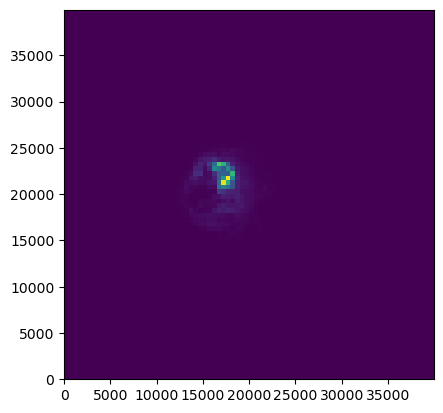

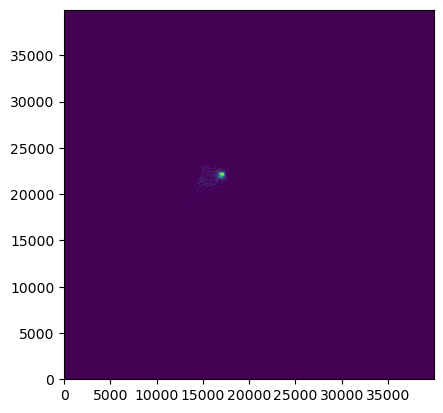

In [20]:
#creates 2 heatmaps, one of absorption and one of emission (exiting the cloud)

out = pandas.read_csv("/Users/kelcy/PYTHON/KNB_PYMC/github/COMMAS_test2_20250122.csv").to_numpy() #array_out[0:50000,:]
out = out[0:50000,:]
#EMITTED
outgrid = np.zeros([len(profile_in['x'])])
# grid_z2 = griddata(out[zp,0]/1e3,out[zp,1]/1e3, values, (grid_x, grid_y), method='cubic')
import numpy as np
import numpy.random
import matplotlib.pyplot as plt
# zp = list(flatten(np.where((dist > 1100.))))
# zp = list(flatten((dist > 500.)))
# zp = list(flatten(np.where((np.array(zeni_arr) >=0.) & (np.array(zeni_arr) <= 2.0))))
# Generate some test data
# x = out[zp,3]#out[zp,0]
# y = out[zp,4]#out[zp,1]
x = out[:,3]
y = out[:,4]
# heatmap, xedges, yedges = np.histogram2d(y, x, range=[[0, np.nanmax(data['XE'])], [0, np.nanmax(data['YE'])]],bins = [len(data['XC']),len(data['YC'])],density = True)
heatmap, xedges, yedges = np.histogram2d(y, x, range=[[0, np.nanmax(profile_in['x'])], [0, np.nanmax(profile_in['x'])]],bins = [80,80],density = False)

extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
# extent = [0, np.nanmax(data['XE']),0, np.nanmax(data['XE'])]

plt.clf()
plt.imshow(heatmap, extent=extent, origin='lower')
plt.show()

#ABSORBED
outgrid = np.zeros([len(profile_in['x']),len(profile_in['x'])])
# zp = list(flatten((dist <= 500.)))
zp = list(flatten(np.where(out[:,6] ==1)))
# Generate some test data
x = out[zp,0]
y = out[zp,1]

heatmap5, xedges5, yedges5 = np.histogram2d(y, x, range=[[0, np.nanmax(profile_in['x'])], [0, np.nanmax(profile_in['x'])]],bins = [len(profile_in['x']),len(profile_in['x'])],density = True)
# extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
extent = [0, np.nanmax(profile_in['x']),0, np.nanmax(profile_in['x'])]

plt.clf()
plt.imshow(heatmap5, extent=extent, origin='lower')
plt.show()

In [9]:
data = xr.open_dataset('/Volumes/Extreme SSD/DATA/ropesville125m/KTAL071015B_30s.002490.nc')

In [65]:
# out #= out5
maxrefl = data['DBZ'].max(axis=1)
mean_mfp = MFP.mean(axis = 0)
frame = 0

# ref_levels = [5,10,15,20,25,30,35,40,45,50,55,60,65,70,75]
ref_levels = [10,20,30,40,50,60,70,80]

photon_levels=[1,3,5,10,20,30,40,50,60,70,80,90,100]
# photon_levels = [1,2,5,10,25,40,65,80,90,125,150,200,350,500]
# photon_levels = [0.005,0.01,0.025,0.05,0.075,0.1,0.25,0.5,0.75,1,1.5,2,2.5,3,3.5,4,4.5,5]
photon_levels = [0.1,0.25,0.5,0.75,1,1.5,2,2.5,3,3.5,4,4.5,5,6,7,8,9,10]

lambda_levels = [1,2,3,5,10,15,25,50,75,100,150,200,350,500,600,800,1000]
tau_levels = [1,10,50,100,150,200,250,300,350,400,450,500,550,600]
# lambda_levels = [1,2,3,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100,125,150,175,200]#25,50,75,100]#,350,500,600,800,1000]

fig, ax = plt.subplots(figsize=(10,10))

refl = maxrefl[0,:,:]#maxrefl[frame,:,:]
# fig.suptitle(str(end))
y_mesh, x_mesh = np.meshgrid(profile_in['x'],profile_in['x'])
ymesh2,xmesh2=np.meshgrid(xedges[0:80],yedges[0:80])
    
# refplt = ax.contour(y_mesh,x_mesh, refl, extend = 'max',levels = ref_levels,cmap='gist_gray',origin = 'lower', vmin=-24, vmax=72, alpha = 1.0)#,extent = [0,-10000,-20000,-10000])

# refplt = ax.contour(y_mesh,x_mesh, refl, extend = 'max',levels = ref_levels,cmap='pyart_LangRainbow12',origin = 'lower', vmin=-24, vmax=72, alpha = 1.0)#,extent = [0,-10000,-20000,-10000])
# refplt = ax.contourf(y_mesh,x_mesh, tau, extend = 'max',levels = tau_levels,cmap='gist_gray',origin = 'lower', alpha = 0.8)#,extent = [0,-10000,-20000,-10000])

# fig.colorbar(refplt,fraction=0.046, pad=0.04)

# refplt2 = ax.contourf(ymesh2, xmesh2, heatmap5, extend = 'max',cmap='Greys_r',levels = photon_levels,origin = 'lower',vmin=1)#,extent = [0,-10000,-20000,-10000])
# refplt2 = ax.contourf(y_mesh, x_mesh, data['QC'].max(axis=1)[0,:,:]*1000, extend = 'max',cmap='Greys_r',alpha = 1.0,origin = 'lower',levels = lambda_levels)#,extent = [0,-10000,-20000,-10000])
# refplt3 = ax.contourf(ymesh2, xmesh2, (heatmap/50000.)*100, extend = 'max',cmap='gist_heat_r',levels = photon_levels,alpha=0.9,origin = 'lower',vmin=1)#,extent = [0,-10000,-20000,-10000])
refplt3 = ax.contourf(y_mesh, x_mesh, mean_mfp, extend = 'max',cmap='Greys_r',alpha = 1.0,origin = 'lower',levels = lambda_levels)#,extent = [0,-10000,-20000,-10000])


# test = (np.reshape(LAM_arr,[160,320,320]))
# LAMreshape = test[32,:,:]
# mask = np.where(LAMreshape < 200)
# pt2 = ax.scatter(data['YC'][mask[1]],data['XC'][mask[0]],marker = '*', color = 'black')

# mask = np.where(LAMreshape < 15)
# # pt2 = ax.scatter(data['YC'][mask[1]],data['XC'][mask[0]],marker = '*', color = 'blue')
# fig.colorbar(refplt2,fraction=0.046, pad=0.04)
fig.colorbar(refplt3,fraction=0.05, pad=0.04)

origin = [5e3,22e3,17e3]
pt2 = ax.scatter(17e3,22e3,marker = 'o' ,color = 'red',s = 25.0)

# ax.scatter(out[:,0], out[:,1], out[:,2])
# ax.set_xlim(0, 140)
# ax.set_ylim(0, 140)
# ax.set_zlim(18e3, 0.)
plt.show()
# fig.suptitle('Light escaping the cloud (percentage)', fontsize=16,y=0.92)
savedir = "/Users/kelcy/PYTHON/KNB_PYMC/github/"
# fig.savefig(savedir+'Light_emitted_percentage_heterogeneous.pdf',format = 'pdf',dpi=1200)



AttributeError: 'numpy.ndarray' object has no attribute 'nanmean'

39.04349669437146
27.481846982236593


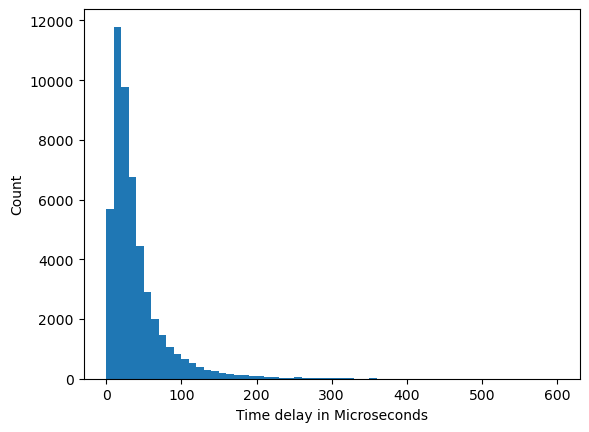

In [146]:
#Evaluate the time delay the photons experienced between emission and exiting the cloud or absorption
# tdelay = out[:,-1]/constants.c
tdelay = newdist/constants.c
print(np.nanmean(tdelay)*1e6)
print(np.median(tdelay)*1e6)
# tdelay*(10**(6))
import matplotlib.pyplot as plt
import numpy as np
fig, axs = plt.subplots(1)#, sharey=True, tight_layout=True)

# We can set the number of bins with the *bins* keyword argument.
axs.hist(tdelay*(10**(6)),bins = [0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200,
                                  210,220,230,240,250,260,270,280,290,300,310,320,330,340,350,360,370,380,390,400,
                                  410,420,430,440,450,460,470,480,490,500,510,520,530,540,550,560,570,580,590,600])
# axs[1].hist(dist2, bins=n_bins)
axs.set_xlabel('Time delay in Microseconds')
axs.set_ylabel('Count')

plt.show()


# plt.hist(tdelay*(10**(6)),bins = [0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200,
#                                   210,220,230,240,250,260,270,280,290,300,310,320,330,340,350,360,370,380,390,400,
#                                   410,420,430,440,450,460,470,480,490,500,510,520,530,540,550,560,570,580,590,600])
# plt.show() 

#Alternative version using plt.hist
# plt.hist(((out[:,-1]/constants.c)*1e6)
#          , bins = [1,5,10,20,30,40,50,75,100,125,150,175,200,225,250,275,300,325,350,400,450,475,500,
#                   525,550,575,600,625,650,675,700,725,750,775,800,825,850,875,900,925,950,975,1000,1100,1200,1300,1400,1500,1600,1700,1800,1900,2000])